# 09 — M5: YOLOv8 Image Classification from Raw UL-DD Video

**Pure vision baseline** — train YOLOv8n-cls directly on driver face frames extracted from UL-DD infrared videos.

Pipeline:
```
IR video (240×220 @ 60fps, ~40 min)
  → Sample at 1 fps → ~2400 frames/video
  → Label by KSS epoch (4-min blocks) → Alert / LowVigilant / Drowsy
  → Resize to 224×224
  → Train YOLOv8n-cls (ImageNet pretrained, transfer learning)
```

Evaluation: 5-fold subject-independent cross-validation (same folds as M1–M3)

| Camera | Subjects | Missing video |
|--------|----------|---------------|
| IR (infrared, face-focused) | 16 / 19 | B, I, M |

In [8]:
import sys, warnings, os, shutil, json, time
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

from ultralytics import YOLO

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT       = Path('..').resolve()
VIDEO_ROOT = Path(r'C:/Users/raka1005/Documents/IISC/UL-DD/Video_Data/Video_Data/Video_Data')
LABELS_CSV = Path(r'C:/Users/raka1005/Documents/IISC/UL-DD/Labels.csv')
FRAME_DIR  = ROOT / 'datasets' / 'yolo_frames'    # extracted frames (once)
YOLO_DIR   = ROOT / 'datasets' / 'yolo_cls'       # per-fold train/val dirs
CKPT_DIR   = ROOT / 'models' / 'checkpoints'
REPORT_DIR = ROOT / 'results' / 'reports'
for d in [FRAME_DIR, YOLO_DIR, CKPT_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
SUBJECTS     = list('ABCDEFGHIJKLMNOPQRS')
NO_VIDEO     = {'B', 'I', 'M'}           # these subjects have no video files
AWAKE_ONLY   = {'C', 'F', 'L'}           # only Alert session exists
SESSION_MAP  = {'Alert': 'A', 'Drowsy': 'D'}
VIDEO_TYPE   = 'IR'                      # infrared face camera

SAMPLE_FPS   = 1.0     # extract 1 frame per second
IMG_SIZE     = 224     # resize for YOLO-cls
EPOCH_SEC    = 240     # 4 minutes per KSS epoch
KSS_THRESH   = (3, 6) # ≤3→Alert, ≤6→LowVigilant, >6→Drowsy
CLASS_NAMES  = ['Alert', 'LowVigilant', 'Drowsy']
N_CLASSES    = 3

FOLDS = [
    list('ABCD'),   # Fold 0
    list('EFGH'),   # Fold 1
    list('IJK'),    # Fold 2
    list('LMNO'),   # Fold 3
    list('PQRS'),   # Fold 4
]

MODEL_NAME = 'M5'
print(f'ROOT       : {ROOT}')
print(f'VIDEO_ROOT : {VIDEO_ROOT}')
print(f'FRAME_DIR  : {FRAME_DIR}')
print('Ready.')

ROOT       : C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system
VIDEO_ROOT : C:\Users\raka1005\Documents\IISC\UL-DD\Video_Data\Video_Data\Video_Data
FRAME_DIR  : C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\datasets\yolo_frames
Ready.


In [2]:
# ── Load KSS labels from Labels.csv ───────────────────────────────────────────

def kss_to_class(kss: float) -> int:
    """Map KSS score (1–9) → 3-class label."""
    if kss <= KSS_THRESH[0]: return 0   # Alert
    if kss <= KSS_THRESH[1]: return 1   # LowVigilant
    return 2                             # Drowsy

def load_labels(csv_path: Path) -> dict:
    """
    Parse Labels.csv → {subject: {session_folder: [10 class ints]}}
    e.g. {'A': {'A': [1,1,1,1,1,1,1,1,1,1], 'D': [1,2,2,2,2,2,2,2,2,2]}}
    """
    labels = defaultdict(dict)
    with open(csv_path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('0'):
                continue
            parts = line.split(',')
            tag = parts[0]                            # e.g. 'A_Alert'
            kss_scores = [float(x) for x in parts[1:]]
            subject = tag.split('_')[0]               # 'A'
            session_name = tag.split('_')[1]          # 'Alert' or 'Drowsy'
            session_folder = SESSION_MAP[session_name] # 'A' or 'D'
            class_labels = [kss_to_class(k) for k in kss_scores]
            labels[subject][session_folder] = class_labels
    return dict(labels)

kss_labels = load_labels(LABELS_CSV)
print(f'Loaded labels for {len(kss_labels)} subjects')
for s in sorted(kss_labels):
    sessions = kss_labels[s]
    for sess, cls in sessions.items():
        dist = {CLASS_NAMES[c]: cls.count(c) for c in range(3) if cls.count(c) > 0}
        print(f'  {s}/{sess}: {dist}')

Loaded labels for 19 subjects
  A/A: {'LowVigilant': 10}
  A/D: {'LowVigilant': 1, 'Drowsy': 9}
  B/A: {'Alert': 2, 'LowVigilant': 8}
  B/D: {'LowVigilant': 2, 'Drowsy': 8}
  C/A: {'Alert': 2, 'LowVigilant': 8}
  D/A: {'Alert': 2, 'LowVigilant': 7, 'Drowsy': 1}
  D/D: {'LowVigilant': 2, 'Drowsy': 8}
  E/A: {'Alert': 7, 'LowVigilant': 3}
  E/D: {'LowVigilant': 2, 'Drowsy': 8}
  F/A: {'Alert': 9, 'LowVigilant': 1}
  G/A: {'LowVigilant': 10}
  G/D: {'LowVigilant': 5, 'Drowsy': 5}
  H/A: {'Alert': 5, 'LowVigilant': 5}
  H/D: {'LowVigilant': 2, 'Drowsy': 8}
  I/A: {'Alert': 10}
  I/D: {'Drowsy': 10}
  J/A: {'Alert': 2, 'LowVigilant': 5, 'Drowsy': 3}
  J/D: {'Drowsy': 10}
  K/A: {'Alert': 1, 'LowVigilant': 9}
  K/D: {'LowVigilant': 2, 'Drowsy': 8}
  L/A: {'LowVigilant': 10}
  M/A: {'Alert': 9, 'LowVigilant': 1}
  M/D: {'LowVigilant': 3, 'Drowsy': 7}
  N/A: {'Alert': 2, 'LowVigilant': 8}
  N/D: {'Drowsy': 10}
  O/A: {'Alert': 7, 'LowVigilant': 3}
  O/D: {'LowVigilant': 5, 'Drowsy': 5}
  P/A: 

In [4]:
# ── Extract face frames from IR videos ────────────────────────────────────────
# Samples at 1 fps, labels each frame by its KSS epoch, resizes to 224×224.
# Saves to: FRAME_DIR / {subject}_{session} / {class_name} / frame_{NNNN}.jpg
# Also builds a metadata DataFrame for fold splitting.

def extract_frames_from_video(
    video_path: Path,
    subject: str,
    session: str,
    epoch_labels: list,
    sample_fps: float = 1.0,
    img_size: int = 224,
) -> list:
    """Extract frames from one video, return list of metadata dicts."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f'  ✗ Cannot open {video_path}')
        return []

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    skip = max(1, int(round(fps / sample_fps)))  # e.g. 60fps / 1fps = 60

    out_dir = FRAME_DIR / f'{subject}_{session}'
    for cn in CLASS_NAMES:
        (out_dir / cn).mkdir(parents=True, exist_ok=True)

    records = []
    frame_idx = 0
    saved = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % skip == 0:
            # Determine KSS epoch
            timestamp_sec = frame_idx / fps
            epoch_idx = min(int(timestamp_sec / EPOCH_SEC), len(epoch_labels) - 1)
            cls = epoch_labels[epoch_idx]
            cls_name = CLASS_NAMES[cls]

            # Resize and save
            resized = cv2.resize(frame, (img_size, img_size))
            fname = f'frame_{saved:05d}.jpg'
            save_path = out_dir / cls_name / fname
            cv2.imwrite(str(save_path), resized)

            records.append({
                'subject': subject,
                'session': session,
                'frame_idx': frame_idx,
                'timestamp_s': round(timestamp_sec, 2),
                'epoch': epoch_idx,
                'class': cls,
                'class_name': cls_name,
                'path': str(save_path),
            })
            saved += 1

        frame_idx += 1

    cap.release()
    return records


# ── Run extraction ────────────────────────────────────────────────────────────
all_meta = []
t0 = time.time()

for subject in sorted(SUBJECTS):
    if subject in NO_VIDEO:
        print(f'[{subject}] No video — skipping')
        continue
    if subject not in kss_labels:
        print(f'[{subject}] No KSS labels — skipping')
        continue

    for session_name, session_folder in SESSION_MAP.items():
        if session_folder not in kss_labels[subject]:
            continue  # e.g. C, F, L have no Drowsy session

        video_name = f'{subject}_{VIDEO_TYPE}_{session_folder}.mp4'
        video_path = VIDEO_ROOT / subject / session_folder / video_name

        if not video_path.exists():
            print(f'[{subject}/{session_folder}] {video_name} not found — skipping')
            continue

        # Check if already extracted
        out_check = FRAME_DIR / f'{subject}_{session_folder}'
        existing = sum(1 for _ in out_check.rglob('*.jpg')) if out_check.exists() else 0
        if existing > 100:
            print(f'[{subject}/{session_folder}] Already extracted ({existing} frames) — skipping')
            # Rebuild metadata from existing files
            for cls_idx, cn in enumerate(CLASS_NAMES):
                for p in sorted((out_check / cn).glob('*.jpg')):
                    all_meta.append({
                        'subject': subject, 'session': session_folder,
                        'class': cls_idx, 'class_name': cn, 'path': str(p),
                    })
            continue

        epoch_labels = kss_labels[subject][session_folder]
        print(f'[{subject}/{session_folder}] Extracting from {video_name} ...', end=' ')
        records = extract_frames_from_video(
            video_path, subject, session_folder,
            epoch_labels, sample_fps=SAMPLE_FPS, img_size=IMG_SIZE,
        )
        all_meta.extend(records)
        print(f'{len(records)} frames')

elapsed = time.time() - t0
meta_df = pd.DataFrame(all_meta)
meta_df.to_csv(FRAME_DIR / 'metadata.csv', index=False)
print(f'\n✓ Total frames: {len(meta_df):,}  |  Time: {elapsed:.0f}s')
print(f'  Saved metadata → {FRAME_DIR / "metadata.csv"}')

[A/A] Already extracted (2400 frames) — skipping
[A/D] Already extracted (2145 frames) — skipping
[B] No video — skipping
[C/A] Already extracted (2400 frames) — skipping
[D/A] Already extracted (2400 frames) — skipping
[D/D] Already extracted (2400 frames) — skipping
[E/A] Already extracted (2400 frames) — skipping
[E/D] Already extracted (2400 frames) — skipping
[F/A] Already extracted (2400 frames) — skipping
[G/A] Already extracted (2400 frames) — skipping
[G/D] Already extracted (2400 frames) — skipping
[H/A] Already extracted (2400 frames) — skipping
[H/D] Already extracted (2400 frames) — skipping
[I] No video — skipping
[J/A] Already extracted (2400 frames) — skipping
[J/D] Already extracted (2400 frames) — skipping
[K/A] Already extracted (2400 frames) — skipping
[K/D] Already extracted (2400 frames) — skipping
[L/A] Already extracted (2400 frames) — skipping
[M] No video — skipping
[N/A] Already extracted (2400 frames) — skipping
[N/D] Already extracted (2361 frames) — skippi

Total frames: 67,780
Subjects with frames: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L', 'N', 'O', 'P', 'Q', 'R', 'S']

Overall class distribution:
  Alert          :  16234  (24.0%)
  LowVigilant    :  26160  (38.6%)
  Drowsy         :  25386  (37.5%)


Total frames: 67,780
Subjects with frames: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L', 'N', 'O', 'P', 'Q', 'R', 'S']

Overall class distribution:
  Alert          :  16234  (24.0%)
  LowVigilant    :  26160  (38.6%)
  Drowsy         :  25386  (37.5%)


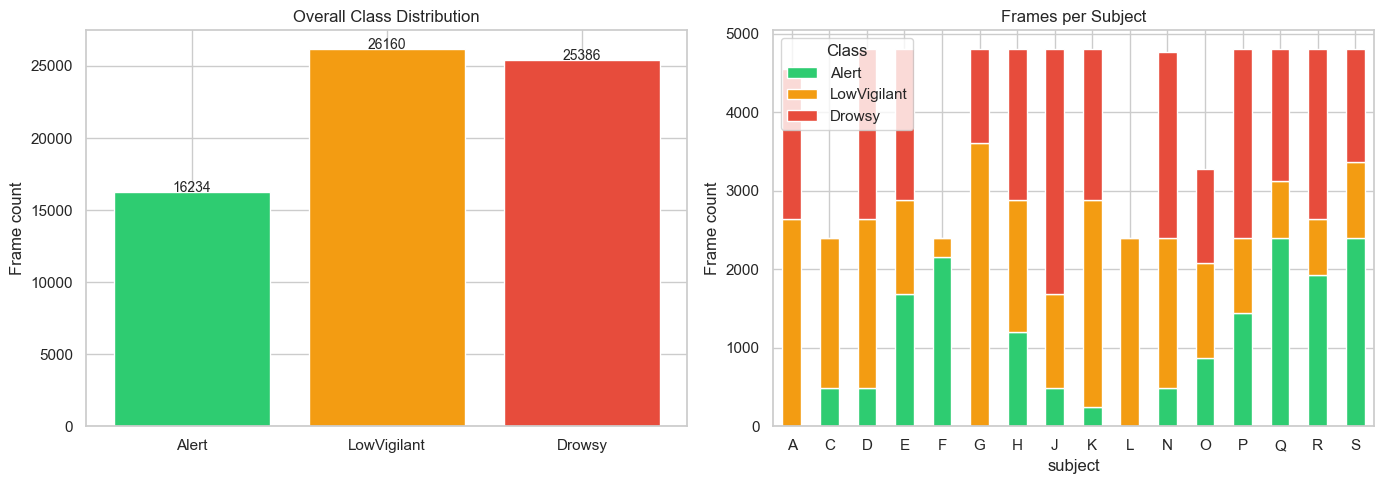

In [5]:
# ── Dataset statistics ─────────────────────────────────────────────────────────
meta_df = pd.read_csv(FRAME_DIR / 'metadata.csv')
print(f'Total frames: {len(meta_df):,}')
print(f'Subjects with frames: {sorted(meta_df["subject"].unique())}')
print()

# Class distribution
cls_counts = meta_df['class_name'].value_counts().reindex(CLASS_NAMES)
print('Overall class distribution:')
for cn, cnt in cls_counts.items():
    print(f'  {cn:15s}: {cnt:6d}  ({cnt/len(meta_df)*100:.1f}%)')

# Per-subject plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — overall
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(CLASS_NAMES, cls_counts.values, color=colors, edgecolor='white')
for i, (cn, cnt) in enumerate(zip(CLASS_NAMES, cls_counts.values)):
    axes[0].text(i, cnt + 50, str(cnt), ha='center', fontsize=10)
axes[0].set_title('Overall Class Distribution')
axes[0].set_ylabel('Frame count')

# Per-subject stacked bar
pivot = meta_df.groupby(['subject', 'class_name']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=CLASS_NAMES, fill_value=0)
pivot.plot.bar(stacked=True, ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Frames per Subject')
axes[1].set_ylabel('Frame count')
axes[1].legend(title='Class')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'M5_frame_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Diagnostic: Pipeline Details & Timing ─────────────────────────────────────
import time, cv2
import numpy as np
from pathlib import Path

print('=' * 65)
print('  M5 YOLOv8-cls — Pipeline Diagnostic Report')
print('=' * 65)

# ── 1. Image details ─────────────────────────────────────────────────────────
print('\n📷  IMAGE DETAILS')
print(f'  Original video resolution : 240 × 220 px (IR camera)')
print(f'  Original video frame rate : 60 fps')
print(f'  Video duration            : ~35–40 min per session')
print(f'  Sampling rate             : {SAMPLE_FPS} fps (1 frame/sec)')
print(f'  Resized frame size        : {IMG_SIZE} × {IMG_SIZE} px')

sample_files = list(FRAME_DIR.rglob('*.jpg'))
total_frames = len(sample_files)
total_bytes  = sum(f.stat().st_size for f in sample_files)
print(f'  Total extracted frames    : {total_frames:,}')
print(f'  Total dataset size        : {total_bytes / 1e9:.2f} GB')
print(f'  Avg file size             : {total_bytes / total_frames / 1024:.1f} KB')

# ── 2. Face region size ──────────────────────────────────────────────────────
print('\n👤  FACE REGION (Haar cascade on sample frames)')
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
widths, heights = [], []
sample_subjects = ['A_A', 'D_D', 'E_A', 'G_D', 'J_A', 'N_D', 'P_A', 'R_D']
for subj in sample_subjects:
    sdir = FRAME_DIR / subj
    if not sdir.exists():
        continue
    for ip in list(sdir.rglob('*.jpg'))[:10]:
        img = cv2.imread(str(ip))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.1, 4)
        for (x, y, w, h) in faces:
            widths.append(w)
            heights.append(h)

if widths:
    print(f'  Detections sampled        : {len(widths)}')
    print(f'  Face width  (mean)        : {np.mean(widths):.0f} px  '
          f'[{min(widths)}–{max(widths)}]')
    print(f'  Face height (mean)        : {np.mean(heights):.0f} px  '
          f'[{min(heights)}–{max(heights)}]')
    print(f'  Face / image ratio        : ~{np.mean(widths)/IMG_SIZE*100:.0f}% of 224 px')
else:
    print('  (No Haar detections — IR images; full frame ≈ face region)')

# ── 3. Model & training config ───────────────────────────────────────────────
print('\n🧠  MODEL & TRAINING CONFIG')
print(f'  Model                     : YOLOv8n-cls (nano)')
print(f'  Pretrained                : ImageNet')
print(f'  Parameters                : ~1.44 M')
print(f'  GFLOPs                    : ~3.4')
print(f'  Input size                : {IMG_SIZE} × {IMG_SIZE}')
print(f'  Epochs                    : {YOLO_EPOCHS}')
print(f'  Batch size                : {YOLO_BATCH}')
print(f'  Optimizer                 : auto (AdamW / SGD)')
print(f'  Learning rate (lr0)       : 1e-3')
print(f'  LR final fraction (lrf)   : 0.01')
print(f'  Dropout                   : 0.3')
print(f'  Early stopping patience   : 15')
print(f'  Cross-validation          : 5-fold subject-independent')
print(f'  Classes                   : {CLASS_NAMES}  (3-class)')

# ── 4. Timing diagnostic (1 fold, small sample) ──────────────────────────────
print('\n⏱  TIMING DIAGNOSTIC (Fold 0, inference only)')
fold_dir = YOLO_DIR / 'fold_0'
best_pt  = CKPT_DIR / 'yolo_cls' / 'M5_fold0' / 'weights' / 'best.pt'

if best_pt.exists():
    # Time: model loading
    t0 = time.perf_counter()
    model = YOLO(str(best_pt))
    t_load = time.perf_counter() - t0

    # Time: prediction on Alert val images (first 500)
    alert_dir = fold_dir / 'val' / 'Alert'
    alert_imgs = sorted(alert_dir.glob('*.jpg'))[:500] if alert_dir.exists() else []

    if alert_imgs:
        # Time: batch prediction
        t0 = time.perf_counter()
        preds = model.predict(source=str(alert_dir), verbose=False, batch=YOLO_BATCH)
        t_predict_all = time.perf_counter() - t0
        n_predicted = len(preds)

        print(f'  Model load time           : {t_load:.2f} s')
        print(f'  Predict {n_predicted:,} images        : {t_predict_all:.1f} s')
        print(f'  Per-image inference        : {t_predict_all/n_predicted*1000:.1f} ms')
        print(f'  Throughput                 : {n_predicted/t_predict_all:.0f} img/s')

        # Estimate full 5-fold eval time
        est_eval = t_predict_all / n_predicted * total_frames
        print(f'  Est. full eval (all folds) : {est_eval:.0f} s ({est_eval/60:.1f} min)')
    else:
        print(f'  Model load time           : {t_load:.2f} s')
        print('  (No val images found for timing)')

    # Estimate training time per fold (from YOLO logs if available)
    results_csv = CKPT_DIR / 'yolo_cls' / 'M5_fold0' / 'results.csv'
    if results_csv.exists():
        import pandas as _pd
        _df = _pd.read_csv(results_csv)
        n_epochs_done = len(_df)
        print(f'  Epochs completed (fold 0) : {n_epochs_done}')
else:
    print('  (No trained model found — run training first)')

print(f'\n{"=" * 65}')
print('  End of diagnostic report')
print(f'{"=" * 65}')

In [13]:
# ── 5-Fold Subject-Independent Cross-Validation ───────────────────────────────
# For each fold:
#   1. Create YOLO-cls folder structure (train/val with class subdirs)
#   2. Hard-link frames (no extra disk space) into the structure
#   3. Train YOLOv8n-cls (pretrained on ImageNet) — SKIPS if best.pt exists
#   4. Load best.pt and evaluate on held-out test subjects

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

meta_df = pd.read_csv(FRAME_DIR / 'metadata.csv')

YOLO_EPOCHS  = 20
YOLO_BATCH   = 32
YOLO_IMGSZ   = 224
YOLO_BASE    = 'yolov8n-cls.pt'   # ImageNet pretrained

all_fold_results = []

for fold_idx, test_subjects in enumerate(FOLDS):
    print(f'\n{"="*60}')
    print(f'  Fold {fold_idx}  |  test subjects = {test_subjects}')
    print(f'{"="*60}')

    # ── Filter subjects that have video ──────────────────────────────────
    test_subs  = [s for s in test_subjects if s not in NO_VIDEO]
    train_subs = [s for s in SUBJECTS if s not in NO_VIDEO
                  and s not in test_subjects]

    test_df  = meta_df[meta_df['subject'].isin(test_subs)]
    train_df = meta_df[meta_df['subject'].isin(train_subs)]

    print(f'  Train: {len(train_df):,} frames from {sorted(train_subs)}')
    print(f'  Test : {len(test_df):,} frames from {sorted(test_subs)}')

    if len(test_df) == 0 or len(train_df) == 0:
        print('  ✗ Insufficient data — skipping fold')
        continue

    # ── Create YOLO directory structure ───────────────────────────────────
    fold_dir = YOLO_DIR / f'fold_{fold_idx}'
    for split in ['train', 'val']:
        for cn in CLASS_NAMES:
            (fold_dir / split / cn).mkdir(parents=True, exist_ok=True)

    # Link/copy frames into train/ and val/
    def _link_frames(df, split):
        linked = 0
        for _, row in df.iterrows():
            src = Path(row['path'])
            if not src.exists():
                continue
            dst = fold_dir / split / row['class_name'] / src.name
            dst = dst.with_name(f"{row['subject']}_{row['session']}_{src.name}")
            if not dst.exists():
                try:
                    os.link(str(src), str(dst))
                except OSError:
                    shutil.copy2(str(src), str(dst))
            linked += 1
        return linked

    # Check if fold already set up
    existing_train = sum(1 for _ in (fold_dir / 'train').rglob('*.jpg')) if (fold_dir / 'train').exists() else 0
    if existing_train > 100:
        print(f'  Fold {fold_idx} dataset already exists ({existing_train} train frames)')
    else:
        n_tr = _link_frames(train_df, 'train')
        n_te = _link_frames(test_df,  'val')
        print(f'  Linked: {n_tr} train + {n_te} val frames')

    # ── Train OR load existing best.pt ────────────────────────────────────
    best_pt = CKPT_DIR / 'yolo_cls' / f'M5_fold{fold_idx}' / 'weights' / 'best.pt'

    if best_pt.exists():
        print(f'  ✓ best.pt already exists — SKIPPING training')
        model = YOLO(str(best_pt))
        print(f'  ✓ Loaded trained model from {best_pt}')
    else:
        print(f'  Training YOLOv8n-cls (epochs={YOLO_EPOCHS}) ...')
        model = YOLO(YOLO_BASE)
        train_results = model.train(
            data    = str(fold_dir),
            epochs  = YOLO_EPOCHS,
            imgsz   = YOLO_IMGSZ,
            batch   = YOLO_BATCH,
            project = str(CKPT_DIR / 'yolo_cls'),
            name    = f'M5_fold{fold_idx}',
            exist_ok = True,
            verbose  = True,
            patience = 15,
            lr0      = 1e-3,
            lrf      = 0.01,
            dropout  = 0.3,
        )
        # Reload the best checkpoint
        if best_pt.exists():
            model = YOLO(str(best_pt))
            print(f'  ✓ Loaded best weights from {best_pt.name}')

    # ── Evaluate with correct class-index mapping ───────────────────────
    # YOLO sorts alphabetically: Alert=0, Drowsy=1, LowVigilant=2
    # Our CLASS_NAMES:            Alert=0, LowVigilant=1, Drowsy=2
    yolo_names = model.names  # e.g. {0:'Alert', 1:'Drowsy', 2:'LowVigilant'}
    yolo_to_ours = {yi: CLASS_NAMES.index(yn) for yi, yn in yolo_names.items()}
    print(f'  Class mapping: {yolo_names}')
    print(f'  yolo→ours: {yolo_to_ours}')

    y_true, y_pred = [], []
    for cn_idx, cn in enumerate(CLASS_NAMES):
        class_dir = fold_dir / 'val' / cn
        if not class_dir.exists():
            continue
        img_list = sorted(class_dir.glob('*.jpg'))
        if not img_list:
            continue
        preds = model.predict(
            source=str(class_dir), verbose=False, batch=YOLO_BATCH
        )
        for p in preds:
            y_true.append(cn_idx)
            y_pred.append(yolo_to_ours[int(p.probs.top1)])

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f'  [Fold {fold_idx}] acc={acc:.4f}  macro_f1={f1:.4f}')

    fold_result = {
        'fold': fold_idx,
        'accuracy': acc,
        'macro_f1': f1,
        'y_true': y_true,
        'y_pred': y_pred,
        'test_subjects': test_subs,
        'n_train': len(train_df),
        'n_test': len(test_df),
    }
    all_fold_results.append(fold_result)

    # Save best weights to main checkpoint dir
    if best_pt.exists():
        dst_pt = CKPT_DIR / f'M5_fold{fold_idx}.pt'
        shutil.copy2(str(best_pt), str(dst_pt))
        print(f'  Saved → {dst_pt}')

# ── Aggregate results ─────────────────────────────────────────────────────────
accs = [f['accuracy'] for f in all_fold_results]
f1s  = [f['macro_f1'] for f in all_fold_results]

results = {
    'model_name': MODEL_NAME,
    'mean_acc': float(np.mean(accs)),
    'std_acc':  float(np.std(accs)),
    'mean_f1':  float(np.mean(f1s)),
    'std_f1':   float(np.std(f1s)),
    'folds':    all_fold_results,
}

print(f'\n{"="*60}')
print(f'=== M5 YOLOv8-cls Results ===')
print(f'Accuracy : {results["mean_acc"]:.4f} ± {results["std_acc"]:.4f}')
print(f'Macro-F1 : {results["mean_f1"]:.4f} ± {results["std_f1"]:.4f}')
print(f'{"="*60}')


  Fold 0  |  test subjects = ['A', 'B', 'C', 'D']
  Train: 56,035 frames from ['E', 'F', 'G', 'H', 'J', 'K', 'L', 'N', 'O', 'P', 'Q', 'R', 'S']
  Test : 11,745 frames from ['A', 'C', 'D']
  Fold 0 dataset already exists (56035 train frames)
  ✓ best.pt already exists — SKIPPING training
  ✓ Loaded trained model from C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\models\checkpoints\yolo_cls\M5_fold0\weights\best.pt
  Class mapping: {0: 'Alert', 1: 'Drowsy', 2: 'LowVigilant'}
  yolo→ours: {0: 0, 1: 2, 2: 1}
  [Fold 0] acc=0.6252  macro_f1=0.5340
  Saved → C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\models\checkpoints\M5_fold0.pt

  Fold 1  |  test subjects = ['E', 'F', 'G', 'H']
  Train: 50,980 frames from ['A', 'C', 'D', 'J', 'K', 'L', 'N', 'O', 'P', 'Q', 'R', 'S']
  Test : 16,800 frames from ['E', 'F', 'G', 'H']
  Fold 1 dataset already exists (50980 train frames)
  ✓ best.pt already exists — SKIPPING training
  ✓ Loaded trained model from 

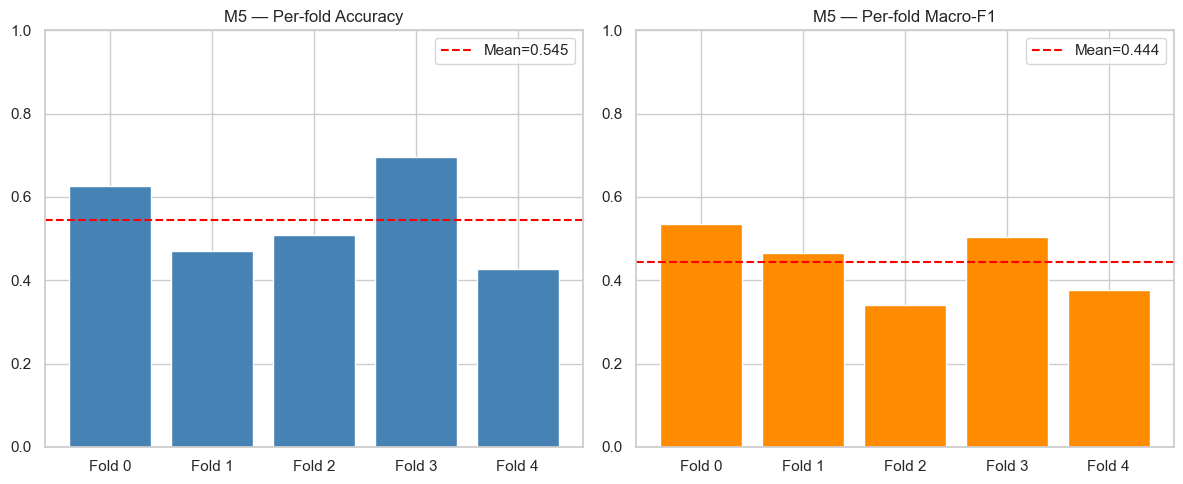

In [14]:
# ── Per-fold results chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

folds_x = [f'Fold {f["fold"]}' for f in all_fold_results]
accs    = [f['accuracy'] for f in all_fold_results]
f1s     = [f['macro_f1'] for f in all_fold_results]

axes[0].bar(folds_x, accs, color='steelblue', edgecolor='white')
axes[0].axhline(np.mean(accs), color='red', ls='--', label=f'Mean={np.mean(accs):.3f}')
axes[0].set_title('M5 — Per-fold Accuracy')
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].bar(folds_x, f1s, color='darkorange', edgecolor='white')
axes[1].axhline(np.mean(f1s), color='red', ls='--', label=f'Mean={np.mean(f1s):.3f}')
axes[1].set_title('M5 — Per-fold Macro-F1')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORT_DIR / 'M5_fold_results.png', dpi=150, bbox_inches='tight')
plt.show()

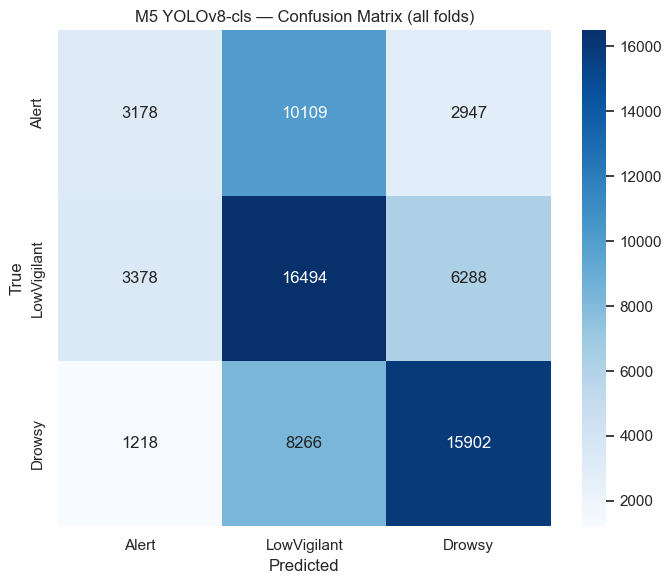

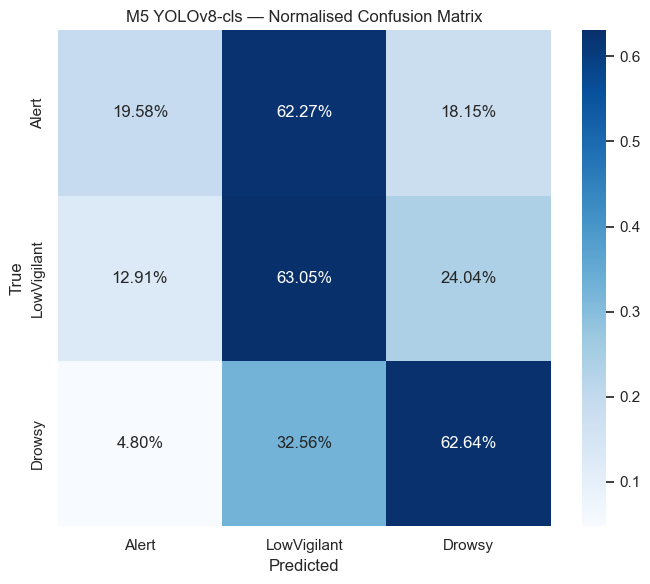

In [15]:
# ── Aggregate confusion matrix ────────────────────────────────────────────────
all_true = []
all_pred = []
for f in all_fold_results:
    all_true.extend(f['y_true'])
    all_pred.extend(f['y_pred'])

cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('M5 YOLOv8-cls — Confusion Matrix (all folds)')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'M5_confusion_matrix.png', dpi=150)
plt.show()

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('M5 YOLOv8-cls — Normalised Confusion Matrix')
plt.tight_layout()
plt.show()

In [16]:
# ── Per-fold results table ────────────────────────────────────────────────────
rows = []
for f in all_fold_results:
    rows.append({
        'Fold': f['fold'],
        'Test Subjects': ', '.join(f['test_subjects']),
        'Train': f['n_train'],
        'Test': f['n_test'],
        'Accuracy': f['accuracy'],
        'Macro-F1': f['macro_f1'],
    })
df = pd.DataFrame(rows)
df.loc['Mean'] = ['', '', df['Train'].mean(), df['Test'].mean(),
                   df['Accuracy'].mean(), df['Macro-F1'].mean()]
df.loc['Std']  = ['', '', '', '', df['Accuracy'].std(), df['Macro-F1'].std()]
df.style.format({'Accuracy': '{:.4f}', 'Macro-F1': '{:.4f}'})

,Fold,Test Subjects,Train,Test,Accuracy,Macro-F1
0,0,"A, C, D",56035.000000,11745.000000,0.6252,0.5340
1,1,"E, F, G, H",50980.000000,16800.000000,0.4696,0.4651
2,2,"J, K",58180.000000,9600.000000,0.5074,0.3393
3,3,"L, N, O",57345.000000,10435.000000,0.6957,0.5048
4,4,"P, Q, R, S",48580.000000,19200.000000,0.4277,0.3763
Mean,,,54224.000000,13556.000000,0.5451,0.4439
Std,,,,,0.1000,0.0745


In [17]:
# ── Save results to JSON for notebook 10 ─────────────────────────────────────
import json

def _to_serializable(obj):
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, dict):           return {k: _to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):           return [_to_serializable(i) for i in obj]
    return obj

save_path = REPORT_DIR / f'{MODEL_NAME}_results.json'
with open(save_path, 'w') as f:
    json.dump(_to_serializable(results), f, indent=2)
print(f'Saved → {save_path}')

print(f'\n=== Final M5 Results ===')
print(f'Accuracy : {results["mean_acc"]:.4f} ± {results["std_acc"]:.4f}')
print(f'Macro-F1 : {results["mean_f1"]:.4f} ± {results["std_f1"]:.4f}')

Saved → C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\results\reports\M5_results.json

=== Final M5 Results ===
Accuracy : 0.5451 ± 0.1000
Macro-F1 : 0.4439 ± 0.0745
